<a href="https://colab.research.google.com/github/APES-M-JeissonS-JuanB/Sesion_4_Regresion_lineal_simple_y_Analisis_de_varianza/blob/main/Sesi%C3%B3n_4_An%C3%A1lisis_de_varianza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 4. Análisis de varianza (ANOVA)

El Análisis de Varianza (ANOVA) es una técnica estadística que evalúa la variabilidad entre grupos en comparación con la variabilidad dentro de esos grupos. Específicamente, descompone la varianza total observada en una variable dependiente en dos componentes: la varianza atribuible a factores explicativos (es decir, las variables independientes en un modelo) y la varianza debida al error o la variabilidad no explicada.

## 4.1 Los supuestos del modelo de regresión lineal

Hasta ahora explicamos cómo aproximar el modelo de regresión lineal:
$$ Y = \alpha + \beta X + \epsilon $$
Por la recta
$$\hat Y =  a + bX$$

Para garantizar que esta aproximación es válida, se deben cumplir las siguientes condiciones:

*    ***Independencia:*** los residuos deben ser independientes entre sí.

La independencia podemos comprobarla con el estadístico de ***Durbin-Watson***. Si éste está entre 1.5 e 2.5, entonces podemos asumir que los residuos son independientes.
*    ***Homocedasticidad:*** para cada valor de la variable X, la varianza de los residuos $e_i=(\hat Y_i - Y_i)$ debe ser la misma (es decir, que el ajuste es igual de preciso independientemente de los valores que tome X).

Para comprobar la homocedasticidad de los residuos, haremos un procedimiento gráfico.
Dibujaremos un diagrama de dispersión de las estimaciones (valores predichos por el modelo) tipificadas (ZPRED) frente a los residuos tipificados (ZRESID).

Para garantizar que hay homocedasticidad, no se debe mostrar ninguna pauta de asociación (ningún patrón) en la nube de puntos.

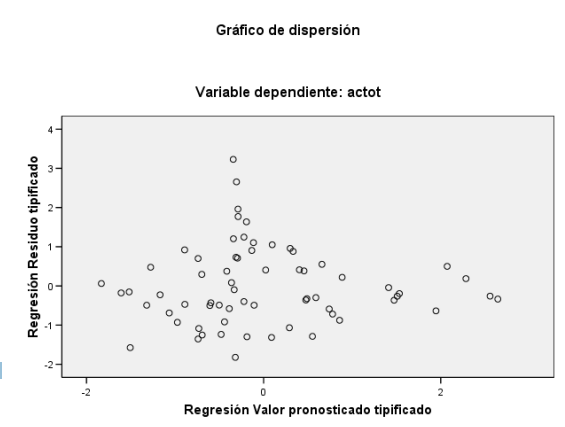

*    ***Normalidad:*** para cada valor de la variable X, los residuos ei tienen distribución normal de
media cero.

Para comprobar la normalidad hacemos los gráficos de normalidad y realizamos el contraste de normalidad (test de Kolmogorov-Smirnov ó
test de Shapiro-Wilks)

In [3]:
from google.colab import drive
drive.mount('/content/drive')
# Importing naumpy and pandas libraries to read the data

# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

# Importar librerias
import numpy as np
import pandas as pd

# Ruta archivo csv
ruta_archivo = "/content/drive/MyDrive/Notebooks/Company_data.csv"

# Leer el archivo CSV en un DataFrame de pandas
advertising = pd.read_csv(ruta_archivo)

# Creating X and y
X = np.array(advertising['TV']).reshape((-1, 1))
y = advertising['Sales']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7,
                                                    test_size = 0.3, random_state = 100)

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)

print('Slope (Coefficient):', model.coef_)
print('Intercept (y-intercept):', model.intercept_)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Slope (Coefficient): [0.05454575]
Intercept (y-intercept): 6.948683200001357


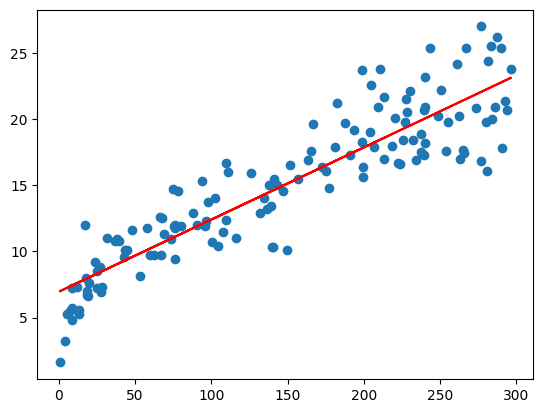

In [4]:
import matplotlib.pyplot as plt
plt.scatter(X_train, y_train)
plt.plot(X_train, 6.948683200001357 + 0.05454575*X_train, 'r')
plt.show()

### Prueba de Durbin-Watson

En términos de regresión lineal simple, la prueba de Durbin-Watson se utiliza para detectar la presencia de autocorrelación en los residuos. Es especialmente relevante cuando se trabaja con series temporales o datos secuenciales, donde la independencia entre observaciones consecutivas puede verse comprometida.

Dicho de manera sencilla, si ajustas una línea a tus datos usando regresión lineal, los residuos son las distancias verticales desde los puntos de datos hasta esa línea. La prueba de Durbin-Watson evalúa si esos residuos están correlacionados entre sí, lo que sería un signo de que hay información en la estructura de los datos que el modelo no está capturando.

$$d=\frac{\sum_{i=2}^n (e_i-e_{i-1})^2}{\sum_{i=1}^n e_i^2}$$

Valores que puede tomar:
El estadístico de Durbin-Watson $d$ varía entre 0 y 4, con las siguientes interpretaciones:

*   $d\approx 2$: No hay evidencia de autocorrelación en la muestra.
*   $0\leq d<2$: Sugerencia de autocorrelación positiva.
*   $2<d\leq4$: Sugerencia de autocorrelación negativa.

In [5]:
from statsmodels.stats.stattools import durbin_watson
residuos = model.predict(X_train) - y_train

# Calcula el estadístico Durbin-Watson
dw_stat = durbin_watson(residuos)
print(f"Estadístico Durbin-Watson: {dw_stat}")

Estadístico Durbin-Watson: 2.1960352247278996


### Pruebas de homocedasticidad

1. ***Gráfico de residuos vs. valores ajustados:*** Esta es una herramienta gráfica donde se trazan los residuos contra los valores ajustados (predicciones) del modelo. Si los puntos están dispersos aleatoriamente alrededor del eje horizontal sin un patrón discernible, es una indicación de homocedasticidad. Si hay un patrón, como una forma de embudo, sugiere heterocedasticidad.


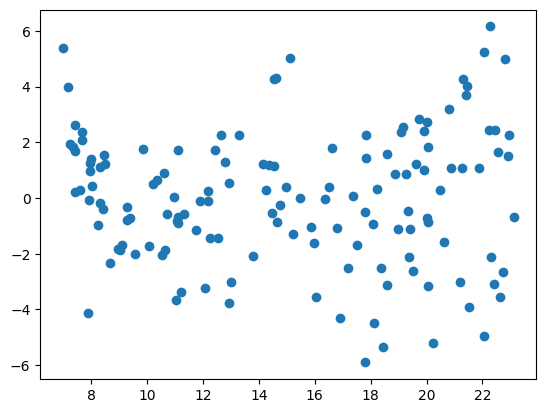

In [6]:
plt.scatter(model.predict(X_train),residuos)
plt.show()

### Ejemplo
En el siguiente ejemplo no se cuenta con el supuesto de homocedasticidad:

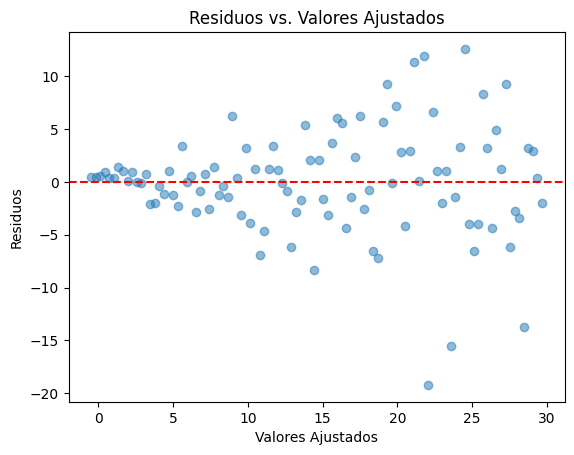

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Configuración de semilla para reproducibilidad
np.random.seed(42)

# Genera datos de muestra con heterocedasticidad
X = np.linspace(0, 10, 100)
y = 3 * X + np.random.normal(0, X, 100)  # Aumentando la varianza con X

# Ajusta el modelo de regresión
X_const = sm.add_constant(X)
model2 = sm.OLS(y, X_const).fit()


# Gráfico de residuos vs. valores ajustados
plt.scatter(model2.predict(X_const), model2.resid, alpha=0.5)
plt.title('Residuos vs. Valores Ajustados')
plt.xlabel('Valores Ajustados')
plt.ylabel('Residuos')
plt.axhline(y=0, color='red', linestyle='--')
plt.show()


Otras pruebas de homocedasticidad son:
2. ***Prueba de Breusch-Pagan:*** Es una prueba estadística que examina si los residuos del modelo son dependientes de las variables en el modelo. Si lo son, es una indicación de heterocedasticidad.

3. ***Prueba de White:*** Es similar a la prueba de Breusch-Pagan, pero es más general y no asume una forma específica de heterocedasticidad.

### Pruebas de normalidad

El supuesto de normalidad en los errores es importante en la regresión lineal, especialmente cuando queremos hacer inferencias acerca de los coeficientes. A continuación, se presentan algunas técnicas ampliamente utilizadas para evaluar este supuesto:

1. ***Histograma de Residuos:*** Una visualización básica donde puedes observar la forma de la distribución de los errores. Si los errores están normalmente distribuidos, el histograma debería tener aproximadamente la forma de una campana.

2. ***Gráfico Q-Q (Quantile-Quantile Plot):*** Un Q-Q plot compara los cuantiles de una distribución con los cuantiles de una distribución normal estándar. Si los puntos siguen aproximadamente una línea recta diagonal (la línea de referencia), indica que los residuos tienen una distribución normal.

3. ***Prueba de Shapiro-Wilk:*** Es una prueba formal para evaluar la normalidad. La hipótesis nula de la prueba es que la población se distribuye normalmente. Si el p-value resultante es menor a un nivel de significancia (por ejemplo, 0.05), se rechaza la hipótesis nula, lo que indica que los datos no se distribuyen normalmente.

4. ***Prueba de Anderson-Darling:*** Es similar a la prueba de Shapiro-Wilk pero pone más peso en las colas de la distribución. Es útil cuando quieres estar especialmente seguro de que los datos no tienen colas pesadas que difieran de una distribución normal.

5. ***Prueba de Kolmogorov-Smirnov:*** Compara la función de distribución acumulativa empírica de los residuos con la función de distribución acumulativa de una distribución normal. Aunque esta prueba es más general y puede usarse para comparar muestras con cualquier distribución, cuando se usa con la normal, puede ayudar a identificar desviaciones de la normalidad.

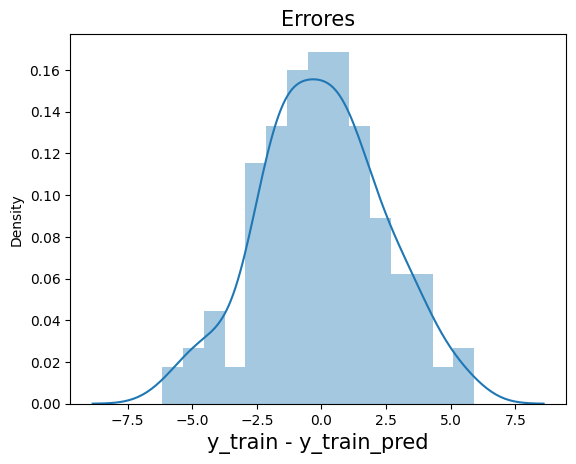

In [8]:
import seaborn as sns

y_train_pred = model.predict(X_train)

# Creating residuals from the y_train data and predicted y_data
res = (y_train - y_train_pred)

fig = plt.figure()
sns.distplot(res, bins = 15)
plt.title('Errores', fontsize = 15)
plt.xlabel('y_train - y_train_pred', fontsize = 15)
plt.show()

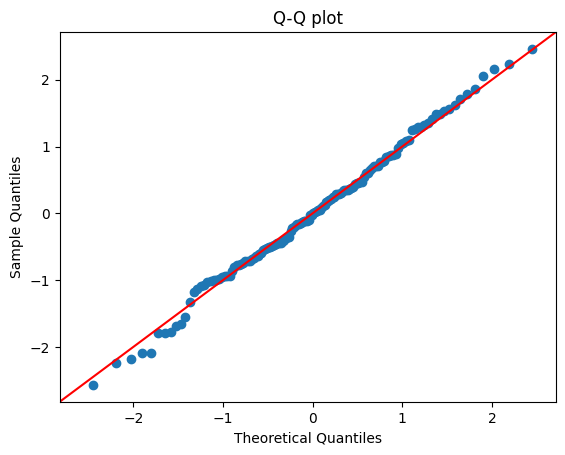

In [9]:
# Gráfico Q-Q
sm.qqplot(res, line='45', fit=True)
plt.title("Q-Q plot")
plt.show()

In [10]:
from scipy.stats import shapiro, anderson, kstest
from scipy import stats
# Prueba de Shapiro-Wilk
shapiro_stat, shapiro_p = shapiro(res)
print(f"Prueba de Shapiro-Wilk: Estadístico = {shapiro_stat}, p-value = {shapiro_p}")


Prueba de Shapiro-Wilk: Estadístico = 0.9940595153119651, p-value = 0.8333568590873535


In [11]:
# Prueba de Anderson-Darling
anderson_result = anderson(residuos)
print(f"Prueba de Anderson-Darling: Estadístico = {anderson_result.statistic}")


Prueba de Anderson-Darling: Estadístico = 0.2193331861799379


In [12]:
# Prueba de Kolmogorov-Smirnov
ks_stat, ks_p = kstest(residuos, stats.norm.cdf)
print(f"Prueba de Kolmogorov-Smirnov: Estadístico = {ks_stat}, p-value = {ks_p}")

Prueba de Kolmogorov-Smirnov: Estadístico = 0.2237359192566195, p-value = 1.2260158164860823e-06


### ANOVA

Se calcula la ANOVA de manera manual de la siguiente manera:

In [13]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Datos simulados
np.random.seed(42)
X = np.random.rand(100, 1) * 10  # Valores aleatorios entre 0 y 10
y = 2.5 * X.squeeze() + 3 + np.random.randn(100) * 2  # Relación lineal con ruido

# Ajuste de modelo lineal
model3 = LinearRegression().fit(X, y)

# Predicciones
y_pred = model.predict(X)

# Suma de cuadrados total
SST = ((y - y.mean())**2).sum()

# Suma de cuadrados de la regresión (explicada)
SSR = ((y_pred - y.mean())**2).sum()

# Suma de cuadrados del error (residual)
SSE = ((y - y_pred)**2).sum()

# Grados de libertad
n = len(y)
p = 1  # Para regresión lineal simple
dof_regression = p
dof_residual = n - p - 1
dof_total = n - 1

# Estadístico F
MSR = SSR / dof_regression
MSE = SSE / dof_residual
F_stat = MSR / MSE

print(f"Suma de Cuadrados de la Regresión (SSR): {SSR}")
print(f"Suma de Cuadrados del Error (SSE): {SSE}")
print(f"Suma de Cuadrados Total (SST): {SST}")
print(f"Estadístico F: {F_stat}")


Suma de Cuadrados de la Regresión (SSR): 5698.646198882249
Suma de Cuadrados del Error (SSE): 10871.630642639533
Suma de Cuadrados Total (SST): 5403.146546853724
Estadístico F: 51.3692329925283


In [14]:
X_train_sm = sm.add_constant(X_train)
lr = sm.OLS(y_train, X_train_sm).fit()
lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     611.2
Date:                Sat, 29 Aug 2026   Prob (F-statistic):           1.52e-52
Time:                        02:13:14   Log-Likelihood:                -321.12
No. Observations:                 140   AIC:                             646.2
Df Residuals:                     138   BIC:                             652.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.9487      0.385     18.068      0.000       6.188       7.709
x1             0.0545      0.002     24.722      0.000       0.050       0.059
==============================================================================
Omnibus:                        0.027   Durbin-Watson:                   2.196
Prob(Omnibus):                  0.987   Jarque-Bera (JB):                0.150
Skew:                          -0.006   Prob(JB):                        0.928
Kurtosis:                       2.840   Cond. No.                         328.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

El estadístico $F$ en el ANOVA se utiliza para determinar si existen diferencias significativas entre los grupos. En el contexto de la regresión, el ANOVA con el estadístico $F$ prueba la hipótesis general de que todos los coeficientes de regresión son iguales a cero (excepto el intercepto).

1. ***R-squared (Coeficiente de Determinación):*** Es una medida que indica qué porcentaje de la variabilidad de la variable dependiente es explicada por el modelo. Valores más cercanos a 1 indican un mejor ajuste del modelo.

2. ***Adj. R-squared (R cuadrado ajustado):*** Similar al R cuadrado, pero ajustado según el número de predictores en el modelo. Es útil para comparar modelos con diferente número de predictores.

3. ***F-statistic (Estadístico F):*** Un valor que indica si al menos una de las variables predictoras tiene un efecto significativo en la variable dependiente. Cuanto mayor es el valor (y más pequeño es el p-value asociado), más evidencia hay contra la hipótesis nula de que todos los coeficientes (excepto el intercepto) son iguales a cero.

4. ***Prob (F-statistic) (p-value del Estadístico F):*** La probabilidad de observar un valor de F al menos tan extremo como el obtenido, si la hipótesis nula es verdadera. Un valor pequeño (generalmente $<0.05$) es una indicación de que al menos una variable predictora es significativa.

5. ***Log-Likelihood (Log-verosimilitud):*** Es el logaritmo de la verosimilitud del modelo. Puede ser útil para comparar diferentes modelos (a través de criterios como AIC y BIC).

6. ***AIC y BIC:*** Criterios de información que combinan la verosimilitud del modelo con una penalización por la complejidad del modelo (basada en el número de parámetros). Son útiles para la selección de modelos.

7. ***coef (coeficientes):*** Estimaciones de los coeficientes de regresión. Indican cómo cambia la variable dependiente por cada unidad de cambio en la variable predictora, manteniendo todas las demás constantes.

8. ***std err (error estándar de los coeficientes):*** Una medida de la variabilidad en las estimaciones de los coeficientes.

9. ***t (Estadístico t):*** Es el valor del coeficiente dividido por su error estándar. Se usa para probar si un predictor es significativamente diferente de 0.

10. ***$P>|t|$*** (p-value del t-estadístico): Probabilidad asociada al estadístico t. Un valor pequeño indica que puedes rechazar la hipótesis nula de que el coeficiente es igual a cero.

11. ***$[0.025 0.975]$ (Intervalo de Confianza):*** El intervalo de confianza al 95% para el coeficiente. Si no contiene el valor 0, indica que el predictor es significativo al nivel del 5%.

In [15]:
# Predecir valores en el conjunto de prueba
y_pred = model.predict(X_test)

###Error Cuadrático Medio (MSE - Mean Squared Error)

Es la media de los cuadrados de los errores (diferencias entre los valores observados y predichos). Penaliza más los errores grandes.

**Interpretación:** Cuanto más bajo es el MSE, mejor es el ajuste del modelo.

In [16]:
# Calcular el Error Cuadrático Medio (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f'MSE: {mse}')

MSE: 4.077556371826948


###Raíz del Error Cuadrático Medio (RMSE - Root Mean Squared Error)
Es la raíz cuadrada del MSE. Da una medida del error en las mismas unidades que la variable dependiente.

**Interpretación:** Igual que el MSE, pero es más fácil de interpretar porque está en las mismas unidades de la variable que estás prediciendo.

In [17]:
rmse = np.sqrt(mse)
print(f'RMSE: {rmse}')

RMSE: 2.019296008966231


### Error Absoluto Medio (MAE - Mean Absolute Error)

Es la media de los valores absolutos de los errores. A diferencia del MSE, el MAE no penaliza tanto los errores grandes.

**Interpretación:** Cuanto más bajo es el MAE, mejor es el ajuste.

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
print(f'MAE: {mae}')

MAE: 1.6480589869746525
